In [4]:
import torch 
import torch.nn as nn

x = torch.arange(10, dtype=torch.long)
y = torch.nn.Embedding(20, 8)
# print(x.unsqueeze(0).expand_as(torch.arange(10)))
x, y

(tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), Embedding(20, 8))

In [5]:
a = torch.rand(2, 3)
b = torch.rand(2,2, 3)
print('a:',a)
print('b:',b)
c = a.expand_as(b)
print('c:',c)

print(a.shape, b.shape, c.shape)



a: tensor([[0.5176, 0.0915, 0.4105],
        [0.9284, 0.8751, 0.0731]])
b: tensor([[[0.5566, 0.1695, 0.6380],
         [0.3701, 0.4064, 0.3272]],

        [[0.9503, 0.7357, 0.5897],
         [0.5126, 0.1839, 0.2192]]])
c: tensor([[[0.5176, 0.0915, 0.4105],
         [0.9284, 0.8751, 0.0731]],

        [[0.5176, 0.0915, 0.4105],
         [0.9284, 0.8751, 0.0731]]])
torch.Size([2, 3]) torch.Size([2, 2, 3]) torch.Size([2, 2, 3])


TypeError: Axes3D.voxels.<locals>.voxels() missing 1 required positional argument: 'filled'

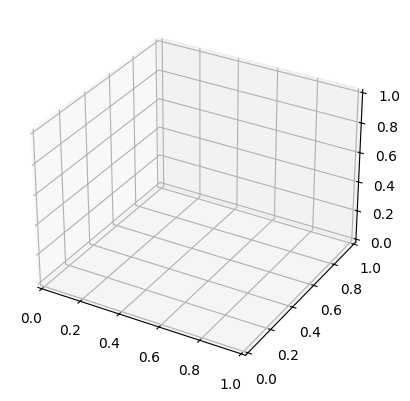

In [6]:
import matplotlib.pyplot as plt

ax = plt.figure().add_subplot(projection="3d")

ax.voxels()

ax.set(xlabel='r', ylabel='g', zlabel='b')
ax.set_aspect('auto')

plt.show()


tensor([[[0.0278, 0.7076, 0.9029],
         [0.1430, 0.2582, 0.6242],
         [0.8019, 0.3217, 0.0275]],

        [[0.1044, 0.5990, 0.8140],
         [0.0085, 0.5286, 0.6379],
         [0.5167, 0.3692, 0.9902]],

        [[0.7482, 0.0845, 0.5484],
         [0.2947, 0.2619, 0.2745],
         [0.3728, 0.9043, 0.4220]]])


/var/folders/fd/mgl6mzys2zl64rvvlypb0y_m0000gn/T/ipykernel_1887/670015134.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


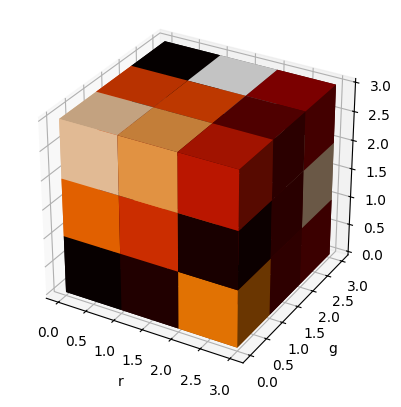

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch

# prepare some coordinates, and attach rgb values to each
tensor_b = torch.rand(3,3, 3)
print(tensor_b)

def number_to_rgb(value, min_value=0, max_value=100, cmap_name='gist_heat'):
    # Normalize et
    t = (value - min_value) / (max_value - min_value)
    t = np.clip(t, 0, 1)

    # Colormap seç
    cmap = cm.get_cmap(cmap_name)
    
    r, g, b, a = cmap(t)

    return ((
        r,
        g,
        b,
        a
    ))

colors = np.zeros(tensor_b.shape + (4,))

max = tensor_b.max() 
min = tensor_b.min()

for idx in np.ndindex(tensor_b.shape):
    colors[idx] = number_to_rgb(tensor_b[idx], min, max)

ax = plt.figure().add_subplot(projection='3d')
ax.voxels(
          tensor_b,
          facecolors=colors,
          linewidth=0.5)
ax.set(xlabel='r', ylabel='g', zlabel='b')
ax.set_aspect('equal')

plt.show()

In [1]:
import pyqtgraph as pg
import pyqtgraph.opengl as gl
import sys
import numpy as np

def create_cube(x, y, z, size, margin=0, color=(1, 0, 0, 1)):
    """
    (x, y, z) merkezli küp oluşturur.

    size: küp boyutu (değişmez)
    margin: küpün konumuna eklenen boşluk (offset)
    """

    # margin ile pozisyon kaydırma
    x += margin
    y += margin
    z += margin

    half = size / 2

    verts = np.array([
        [x - half, y - half, z - half],
        [x + half, y - half, z - half],
        [x + half, y + half, z - half],
        [x - half, y + half, z - half],
        [x - half, y - half, z + half],
        [x + half, y - half, z + half],
        [x + half, y + half, z + half],
        [x - half, y + half, z + half],
    ])

    faces = np.array([
        [0,1,2], [0,2,3],
        [4,5,6], [4,6,7],
        [0,1,5], [0,5,4],
        [2,3,7], [2,7,6],
        [1,2,6], [1,6,5],
        [0,3,7], [0,7,4],
    ])

    return gl.GLMeshItem(
        vertexes=verts,
        faces=faces,
        smooth=False,
        drawEdges=False,
        drawFaces=True,
        color=color
    )
# 1. Uygulamayı başlat
app = pg.mkQApp("3D Izgara Gorunumu")

# 2. 3D Görüntüleme widget'ını oluştur
view = gl.GLViewWidget()
view.show()
view.setWindowTitle('pyqtgraph: 3D Grid Zoom ve Hareket')

# Kamerayı başlangıçta biraz uzaklaştıralım (Yakınlaşma/Uzaklaşma sorunu için)
view.setCameraPosition(distance=20)

## 3. Izgaraları (Grids) oluştur
xgrid = gl.GLGridItem()
ygrid = gl.GLGridItem()
zgrid = gl.GLGridItem()

gl.GLTextItem()

# ## 4. Izgaraları ekle
# view.addItem(xgrid)
# view.addItem(ygrid)
# view.addItem(zgrid)
# txt = gl.GLTextItem()
# txt.text = "merhaba dünya"


box  = gl.GLBoxItem()
box.setSize(10,10,10)

# Küp vertexleri
verts = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [1, 1, 0],
    [0, 1, 0],
    [0, 0, 1],
    [1, 0, 1],
    [1, 1, 1],
    [0, 1, 1]
])
# Üçgen yüzeyler
faces = np.array([
    [0,1,2], [0,2,3],
    [4,5,6], [4,6,7],
    [0,1,5], [0,5,4],
    [2,3,7], [2,7,6],
    [1,2,6], [1,6,5],
    [0,3,7], [0,7,4]
])

mesh = gl.GLMeshItem(
    vertexes=verts,
    faces=faces,
    smooth=False,
    drawEdges=False,   # sadece çizgi olmasın
    drawFaces=True,    # yüzeyleri doldur
    color=(1, 0, 0, 1)
)

view.addItem(mesh)

# box.setColor("#ffff")
# view.addItem(box)
cube = create_cube(
    x=0, y=0, z=0,
    size=1,
    margin=2,
    color=(0, 1, 0, 1)
)
cube2 = create_cube(
    x=2, y=0, z=0,
    size=1,
    margin=2,
    color=(1, 0, 0, 1)
)
cube3 = create_cube(
    x=3, y=0, z=0,
    size=1,
    margin=2,
    color=(1, 0, 0, 1)
)

view.addItem(cube)
view.addItem(cube2)
view.addItem(cube3)
# view.addItem(txt)

## 5. Eksenleri yönlendir
# X ve Y ızgaralarını dik hale getiriyoruz
xgrid.rotate(90, 0, 1, 0)
ygrid.rotate(90, 1, 0, 0)

## 6. Ölçeklendirme
xgrid.scale(0.2, 0.1, 0.1)
ygrid.scale(0.2, 0.1, 0.1)
zgrid.scale(0.1, 0.2, 0.1)

## 7. Uygulamanın çalışır kalmasını sağla
if __name__ == '__main__':
    # Bu satır etkileşimi (zoom, rotate) aktif eder
    if (sys.flags.interactive != 1) or not hasattr(pg, 'QtCore'):
        sys.exit(app.exec_())

SystemExit: 0

/opt/anaconda3/envs/lang/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [1]:
import pyqtgraph as pg
import pyqtgraph.opengl as gl
import sys
import numpy as np

def create_cube_mesh(x, y, z, size=0.8, color=(0.2, 0.7, 1, 0.6)):
    """Belirlenen x,y,z koordinatında bir küp oluşturur."""
    half = size / 2
    verts = np.array([
        [x - half, y - half, z - half],
        [x + half, y - half, z - half],
        [x + half, y + half, z - half],
        [x - half, y + half, z - half],
        [x - half, y - half, z + half],
        [x + half, y - half, z + half],
        [x + half, y + half, z + half],
        [x - half, y + half, z + half],
    ])
    faces = np.array([
        [0,1,2], [0,2,3], [4,5,6], [4,6,7],
        [0,1,5], [0,5,4], [2,3,7], [2,7,6],
        [1,2,6], [1,6,5], [0,3,7], [0,7,4],
    ])
    return gl.GLMeshItem(vertexes=verts, faces=faces, smooth=False, drawEdges=True, edgeColor=(0,0,0,1), drawFaces=True, color=color)

def visualize_tensor(view_widget, tensor, threshold=0.5):
    """
    3B Tensörü görselleştirir. 
    Eşik değerinden büyük olan her hücre bir küp olarak çizilir.
    """
    # Tensör boyutlarını al
    dx, dy, dz = tensor.shape
    
    for i in range(dx):
        for j in range(dy):
            for k in range(dz):
                val = tensor[i, j, k]
                if val > threshold:
                    # Değere göre renk belirle (Opsiyonel: Daha yüksek değer daha parlak)
                    color = (val, 0.2, 1.0 - val, 0.8) 
                    cube = create_cube_mesh(i, j, k, size=0.9, color=color)
                    view_widget.addItem(cube)

# 1. Uygulamayı başlat
app = pg.mkQApp("Tensör Görselleştirme")

# 2. 3D Görüntüleme widget'ı
view = gl.GLViewWidget()
view.show()
view.setWindowTitle('PyQtGraph: 3D Tensör Görünümü')
view.setCameraPosition(distance=15)

# 3. Örnek Bir Tensör Oluştur (Rastgele veya belirli bir şekil)
# Örn: 5x5x5 boyutunda rastgele değerler
np.random.seed(42)
data_tensor = np.random.rand(500, 500, 500)

# 4. Izgara (Grid) ekleyelim (Zemin referansı için)
grid = gl.GLGridItem()
grid.scale(1, 1, 1)
view.addItem(grid)

# 5. Tensörü Görselleştir
visualize_tensor(view, data_tensor, threshold=0.7)

# 6. Uygulamanın çalışır kalmasını sağla
if __name__ == '__main__':
    if (sys.flags.interactive != 1) or not hasattr(pg, 'QtCore'):
        sys.exit(app.exec_())

KeyboardInterrupt: 

In [ ]:
import pyqtgraph as pg
import pyqtgraph.opengl as gl
import numpy as np
import sys

def visualize_tensor_scatter(view_widget, tensor, threshold=0.1, dot_size=5):
    """
    Tensörü GLScatterPlotItem kullanarak çok hızlı şekilde görselleştirir.
    """
    # 1. Eşik değerini geçen hücrelerin indekslerini bul (Vektörize işlem)
    # indices: (N, 3) boyutunda bir dizi döner (x, y, z koordinatları)
    indices = np.argwhere(tensor > threshold)
    
    if len(indices) == 0:
        print("Görselleştirilecek veri bulunamadı (Eşik değeri çok yüksek olabilir).")
        return

    # 2. Renkleri belirle (Opsiyonel: Tensör değerine göre dinamik renk)
    # Değerleri 0-1 arasına normalize ederek renk paletine döküyoruz
    values = tensor[tensor > threshold]
    
    # RGBA formatında renk dizisi oluştur (N, 4)
    colors = np.empty((len(values), 4))
    colors[:, 0] = values          # Kırmızı kanal (Yoğunluğa bağlı)
    colors[:, 1] = 1 - values      # Yeşil kanal
    colors[:, 2] = 0.5             # Mavi kanal
    colors[:, 3] = 0.8             # Alpha (Saydamlık)

    # 3. Scatter Plot nesnesini oluştur
    scatter = gl.GLScatterPlotItem(
        pos=indices,          # Noktaların koordinatları
        color=colors,         # Noktaların renkleri
        size=dot_size,        # Nokta büyüklüğü (piksel cinsinden)
        pxMode=True           # True ise zoom yapsanız da nokta boyutu sabit kalır (Hızlıdır)
    )
    
    view_widget.addItem(scatter)
    return scatter

# --- Uygulama Kurulumu ---
app = pg.mkQApp("Scatter Tensör Görünümü")
view = gl.GLViewWidget()
view.show()
view.setCameraPosition(distance=50)

# Örnek: Yüksek boyutlu bir tensör (Örn: 50x50x50)
# Bu 125.000 hücre demektir, Mesh ile çok kasar ama Scatter ile akıcıdır.
shape = (50, 50, 50)
data = np.random.rand(*shape)

visualize_tensor_scatter(view, data, threshold=0.2)

if __name__ == '__main__':
    if (sys.flags.interactive != 1) or not hasattr(pg, 'QtCore'):
        sys.exit(app.exec_())

SystemExit: 0

/opt/anaconda3/envs/lang/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
